In [1]:
import pandas as pd

In [24]:
data=pd.read_csv("data.csv")
data.head()

,Height,Weight
0,147,52.21
1,150,53.12
2,152,54.48
3,155,55.84
4,157,57.20


In [25]:
x=data.iloc[:,:-1]
x.head()

,Height
0,147
1,150
2,152
3,155
4,157


In [26]:
y=data["Weight"]
y

0     52.21
1     53.12
2     54.48
3     55.84
4     57.20
5     58.57
6     59.93
7     61.29
8     63.11
9     64.47
10    66.28
11    68.10
12    69.92
13    72.19
14    74.46
Name: Weight, dtype: float64

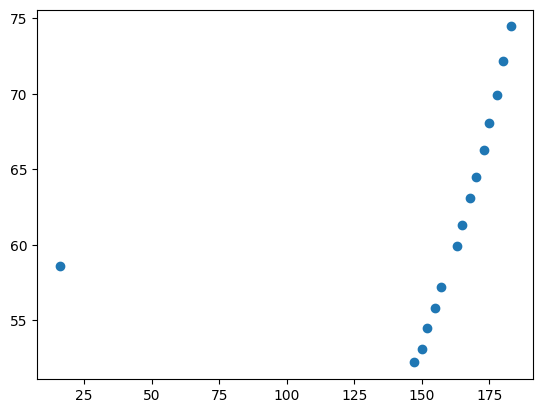

In [27]:
import matplotlib.pyplot as plt
plt.scatter(x,y)
plt.show()

In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Height  15 non-null     int64  
 1   Weight  15 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 372.0 bytes


In [29]:
data.describe()

,Height,Weight
count,15.000000,15.000000
mean,155.466667,62.078000
std,40.213478,7.037515
min,16.000000,52.210000
25%,153.500000,56.520000
50%,165.000000,61.290000
75%,174.000000,67.190000
max,183.000000,74.460000


In [30]:
data.corr() *100

,Height,Weight
Height,100.000000,41.002954
Weight,41.002954,100.000000


In [31]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.2, random_state = 42)
x_train.shape

(12, 1)

In [32]:
y_train.shape

(12,)

In [33]:
x_test.shape

(3, 1)

In [34]:
y_test.shape

(3,)

In [35]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [36]:
from sklearn.metrics import r2_score
model.predict([[155]])

C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([62.30498107])

In [37]:
y_pred=model.predict(x_test)

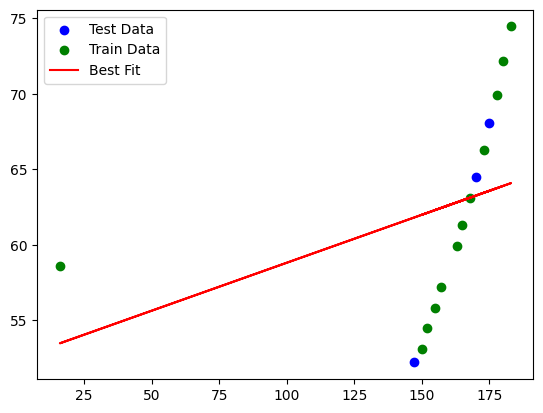

In [38]:
plt.scatter(x_test, y_test, color="blue", label="Test Data")
plt.scatter(x_train, y_train, color="green", label="Train Data")
plt.plot(x_train, model.predict(x_train), color="red", label="Best Fit")
plt.legend()
plt.show()

In [39]:
evaluation = pd.DataFrame({"Actual Value" : y_test,
"Predicted Value" : y_pred,
"Bias/ Error" : y_test - y_pred})
evaluation

,Actual Value,Predicted Value,Bias/ Error
9,64.47,63.257311,1.212689
11,68.10,63.574754,4.525246
0,52.21,61.797072,-9.587072


In [40]:
import joblib

In [41]:
joblib.dump(model,"weight_predictor.joblib")

['weight_predictor.joblib']